# College Physics 12th Edition

<img src="..//pics/cover.png" width=400> 



In [2]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1


<IPython.core.display.Javascript object>

All imports succeeded!


In [3]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec, oom


In [4]:
!python --version

Python 3.12.10


In [5]:
pwd


'c:\\Users\\crodr\\BK_tech\\Physics\\BK_College_Physics_Serway_12\\ch01'

# Topic 1 - Units, Trigonometry, and Vectors



## Problems
### 1.4 Vectors

#### 61. 

page 27

61. A vector $\vec{A}$ has components $Ax = -5.00 m$ and $Ay = 9.00 m$.
Find 

**(a)** the magnitude and 

**(b)** the direction of the vector.

In [5]:
A = vp.vec(-5.00, 9.00, 0)

theta = vp.degrees(vp.atan2(A.y, A.x))

print(f"A <{A.mag:.3g} m, {theta:.3g}°>")

A <10.3 m, 119°>


#### 62. 

A person walks 25.0° north of east for 3.10 km. How far due
north and how far due east would she have to walk to arrive at
the same location?

In [ ]:
theta = vp.radians(25.0)
r_mag = 3.10  # km
r = vp.vec(r_mag * vp.cos(theta), r_mag * vp.sin(theta), 0)

print(f"r{fmt_vec(r)} km")

r<2.81, 1.31, 0.00> km


#### 63. 

The magnitude of vector $\vec{A}$ 35.0 units and points in 
the direction 325° counterclockwise from the positive x-axis.
Calculate the x - and y - components of this vector.

In [ ]:
theta = vp.radians(325)
r_mag = 35.0  # km
r = vp.vec(r_mag * vp.cos(theta), r_mag * vp.sin(theta), 0)

print(f"r{fmt_vec(r, 1)} units")

r<28.7, -20.1, 0.0> units


#### 64. 

A figure skater glides along a circular path of radius 5.00 m. If
she coasts around one half of the circle, find 

**(a)** her distance from the starting location and 

**(b)** the length of the path she skated.

In [ ]:
r = 5.00 * u.m
distance = 2 * r
length = (1 / 2) * 2 * np.pi * r

print(f"--- (a)---: distance from start: {distance:.1f}")
print(f"--- (b)---: length of the path: {length:.3g}")


--- (a)---: distance from start: 10.0 m
--- (b)---: length of the path: 15.7 m


#### 65. 

A girl delivering newspapers covers her route by traveling
3.00 blocks west, 4.00 blocks north, and then 6.00 blocks east.

**(a)** What is her final position relative to her starting location?

**(b)** What is the length of the path she walked?

In [ ]:
d1 = vp.vec(-3, 0, 0)
d2 = vp.vec(0, 4, 0)
d3 = vp.vec(6, 0, 0)

d = d1 + d2 + d3

d_mag = d.mag
theta = vp.degrees(vp.atan2(d.y, d.x))

path = d1.mag + d2.mag + d3.mag

print(f"\n--- (a)---")
print(f"Position coordinates: {fmt_vec(d)} blocks")
print(f"Position vector: <{d_mag:.2f} blocks, {theta:.1f}°>")

print(f"\n--- (b)---")
print(f"length of the path: {path:.1f} blocks")



--- (a)---
Position coordinates: <3.00, 4.00, 0.00> blocks
Position vector: <5.00 blocks, 53.1°>

--- (b)---
length of the path: 13.0 blocks


#### 66. 

A football midfielder receives the ball, dribbles backward
for 10.0 yards, and then runs sideways across the field for
15.0 yards. At this point, he kicks a 50.0-yard pass straight
upfield to a striker. How far is the football from its original
location?

In [ ]:
d1 = vp.vec(0, -10, 0)
d2 = vp.vec(15, 0, 0)
d3 = vp.vec(0, 50, 0)

r = d1 + d2 + d3

print(f"Displacement: {r.mag:.3g} yards")


Displacement: 42.7 yards


Plot the vectors:

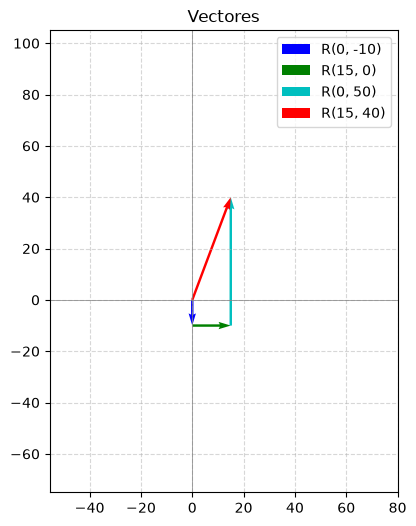

In [ ]:
# Import your helper function directly
from helper_functions import plot_vector, plot_vector_xy


fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# just in case is needed we can use ret, normally not use
ret_1 = plot_vector_xy(d1.x, d1.y, ax=ax, color="b", label="R(0, -10)")
ret_2 = plot_vector_xy(
    d2.x, d2.y, origin=(d1.x, d1.y), ax=ax, color="g", label="R(15, 0)"
)
ret_3 = plot_vector_xy(
    d3.x, d3.y, origin=(d1.x + d2.x, d1.y + d2.y), ax=ax, color="c", label="R(0, 50)"
)
ret_4 = plot_vector_xy(r.x, r.y, ax=ax, color="r", label="R(15, 40)")


plt.title("Vectores")
plt.show()

#### 67. 
A vector has an x-component of -25.0 units and a y-component
of 40.0 units. Find the magnitude and direction of the vector.

In [74]:
r = vp.vec(-25.0, 40.0, 0)

theta = vp.degrees(vp.atan2(r.y, r.x))

print(f"Vector: <{r.mag:.3g} units, {theta:.3g}°>")


Vector: <47.2 units, 122°>


#### 68. 

A map of South Korea suggests that Daegu is 155 km in a
direction 22.5° north of east from Gwangju. The same map
shows that Seoul is 203 km in a direction 36.0° west of north
from Daegu. Figure P1.68 shows the location of these three
cities. Modeling the Earth as flat, use this information to find
the displacement from Gwangju to Seoul.

<img src="..//pics/Fig_P1_68.png" width=400> 


In [ ]:
d1_mag = 155  # km
d1_theta = vp.radians(22.5)
d2_mag = 203  # km
d2_theta = vp.radians(90 + 36.0)

d1 = vp.vec(d1_mag * vp.cos(d1_theta), d1_mag * vp.sin(d1_theta), 0)
d2 = vp.vec(d2_mag * vp.cos(d2_theta), d2_mag * vp.sin(d2_theta), 0)

d = d1 + d2
d_theta = vp.degrees(vp.atan2(d.y, d.x))

print(f"Displacement: <{d.mag:.3g} km, {d_theta:.3g}°>")


Displacement: <225 km, 83.9°>


#### 69. 

The eye of a hurricane passes over Grand Bahama Island
in a direction 60.0° north of west with a speed of 41.0 km/h.
Three hours later the course of the hurricane suddenly shifts
due north, and its speed slows to 25.0 km/h. How far from
Grand Bahama is the hurricane 4.50 h after it passes over the
island?

In [ ]:
v1_mag = 41.0  # km/h
v1_theta = vp.radians(180 - 60)
t1 = 3  # h

v2 = vp.vec(0, 25.0, 0)
t_total = 4.50  # h

# calculations

v1 = vp.vec(v1_mag * vp.cos(v1_theta), v1_mag * vp.sin(v1_theta), 0)
t2 = t_total - t1

# from eq: v = d / t ==> d = v.t
d = t1 * v1 + t2 * v2  # displacement
d_theta = vp.degrees(vp.atan2(d.y, d.x))

print(f"Displacement: <{d.mag:.3g} km, {d_theta:.3g}°>")


Displacement: <157 km, 113°>


#### 70. 
The helicopter view in Figure P1.70 shows two people pulling
on a stubborn mule. Find 

**(a)** the single force that is
equivalent to the two forces shown and 

**(b)** the force a third
person would have to exert on the mule to make the net
force equal to zero. The forces are measured in units of
newtons (N).

<img src="..//pics/Fig_P1_70.png" width=300> 



In [ ]:
F1_mag = 120  # N
F1_theta = vp.radians(60.0)

F2_mag = 80.0  # N
F2_theta = vp.radians(180 - 75.0)

# calculations

F1 = vp.vec(F1_mag * vp.cos(F1_theta), F1_mag * vp.sin(F1_theta), 0)
F2 = vp.vec(F2_mag * vp.cos(F2_theta), F2_mag * vp.sin(F2_theta), 0)

F_net = F1 + F2
F_net_theta = vp.degrees(vp.atan2(F_net.y, F_net.x))

F3 = -F_net
F3_theta = (vp.degrees(vp.atan2(F3.y, F3.x))) % 360

print("\n--- (a) ---")
print(f"Fuerza resultante: <{F_net.mag:.3g} N, {F_net_theta:.3g}°>")

print("\n--- (B) ---")
print(f"Third person force: <{F3.mag:.3g} N, {F3_theta:.3g}°>")



--- (a) ---
Fuerza resultante: <185 N, 77.8°>

--- (B) ---
Third person force: <185 N, 258°>


Plot the vectors:

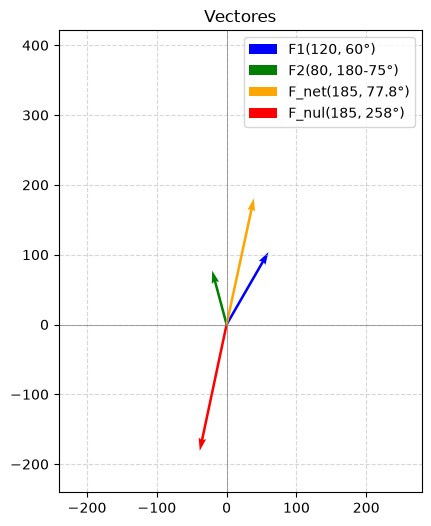

In [ ]:
# Import your helper function directly
from helper_functions import plot_vector, plot_vector_xy


fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# just in case is needed we can use ret, normally not use
ret_1 = plot_vector(120, 60, ax=ax, color="b", label="F1(120, 60°)")
ret_2 = plot_vector(80, 180 - 75, ax=ax, color="g", label="F2(80, 180-75°)")
ret_3 = plot_vector(185, 77.8, ax=ax, color="orange", label="F_net(185, 77.8°)")
ret_3 = plot_vector(185, 258, ax=ax, color="r", label="F_nul(185, 258°)")


plt.title("Vectores")
plt.show()

#### 71. 
A commuter airplane starts from an airport and takes the
route shown in Figure P1.71. The plane first flies to city
A, located 175 km away in a direction 30.0° north of east.
Next, it flies for 150. km 20.0° west of north, to city B.
Finally, the plane flies 190. km due west, to city C. Find
the location of city C relative to the location of the starting
point.

<img src="..//pics/Fig_P1_71.png" width=300> 


In [ ]:
a_mag = 175  # km
a_theta = vp.radians(30.0)
b_mag = 150  # km
b_theta = vp.radians(90 + 20.0)
c = vp.vec(-190, 0, 0)

# calculaltions
a = vp.vec(a_mag * vp.cos(a_theta), a_mag * vp.sin(a_theta), 0)
b = vp.vec(b_mag * vp.cos(b_theta), b_mag * vp.sin(b_theta), 0)

R = a + b + c
R_theta = vp.degrees(vp.atan2(R.y, R.x))

print(f"Location of c: <{R.mag:.3g} km, {R_theta:.1f}°>")


Location of c: <245 km, 111.4°>
